# ASOS 1-Minute Data Pipeline

Fetch TRUE per-minute precipitation and weather data from ASOS stations via IEM.

**Source:** https://mesonet.agron.iastate.edu/request/asos/1min.phtml

## Key Features
- 1-min `precip` = TRUE precipitation per minute (not hourly running totals)
- Flexible resampling to any interval (5min, 10min, 15min, 1H, etc.)
- Precipitation type classification (rain, snow, freezing rain, etc.)

## Pipeline Steps
1. Fetch raw 1-minute data (monthly chunks)
2. Convert to metric units
3. Resample to desired interval
4. Analyze precipitation types
5. Plot and save results

In [10]:
# Cell 1: Setup
from datetime import datetime
from pathlib import Path
import sys
import warnings
warnings.filterwarnings('ignore')

# Add src directory to path for config import
sys.path.insert(0, str(Path().resolve().parent))

from config import NOAA_DIR

from asos_functions import (
    STATIONS,
    fetch_all_stations_1min,
    process_all_stations,
    resample_all_stations,
    compute_accumulated_all,
    get_precip_type_summary,
    filter_by_precip_type,
    save_data,
    load_data,
    check_format,
    plot_precipitation_subplots,
    plot_weather_subplots,
    plot_accumulated,
    plot_precip_by_type
)

import matplotlib.pyplot as plt
import pandas as pd

# CONFIG
STATION_IDS = ['JFK', 'LGA', 'NYC']
START_DATE = datetime(2023, 8, 1)
END_DATE   = datetime(2025, 11, 10)
DATA_DIR = NOAA_DIR / 'noaa_asos_1min'  # Input/Output directory

print(f'Stations: {STATION_IDS}')
print(f'Period: {START_DATE.date()} to {END_DATE.date()}')
print(f'Data directory: {DATA_DIR}')
print('✓ Setup complete')

Stations: ['JFK', 'LGA', 'NYC']
Period: 2023-08-01 to 2025-11-10
Data directory: /Users/drorjac/OpenMesh_pynncml/src/data/noaa_asos/noaa_asos_1min
✓ Setup complete


## Option A: Load Existing Data

Skip fetching and load previously saved data from disk.

In [12]:
# Cell 1b: Load existing data (OPTION A - skip fetch)
# Set LOAD_EXISTING = True to load from disk instead of fetching

LOAD_EXISTING = True  # <-- Change to True to load existing data

if LOAD_EXISTING:
    processed_data = load_data(DATA_DIR, prefix='1min', station_ids=STATION_IDS)
    
    # Check format
    format_results = check_format(processed_data)
    
    # Summary
    print(f'Loaded {len(processed_data)} stations')
    for sid, df in processed_data.items():
        print(f'  {sid}: {len(df):,} rows, {df["time"].min()} to {df["time"].max()}')

Loading from: /Users/drorjac/OpenMesh_pynncml/src/data/noaa_asos/noaa_asos_1min


ValueError: Missing column provided to 'parse_dates': 'time'

## Option B: Fetch New Data

Fetch fresh data from IEM servers (takes time).

In [24]:
import requests
from io import StringIO
import pandas as pd

url = "https://mesonet.agron.iastate.edu/cgi-bin/request/asos1min.py"

# Test with original working vars
params = {
    'station': 'JFK',
    'tz': 'UTC',
    'year1': 2024, 'month1': 1, 'day1': 1,
    'year2': 2024, 'month2': 1, 'day2': 2,
    'vars': 'tmpf,dwpf,sknt,drct,precip',
    'sample': '1min',
    'what': 'download',
    'delim': 'comma',
}
response = requests.get(url, params=params, timeout=60)
print(f"Original vars - Status: {response.status_code}, Length: {len(response.text)}")

# Test with new vars
params['vars'] = 'tmpf,dwpf,sknt,drct,gust_sknt,gust_drct,ptype,precip'
response = requests.get(url, params=params, timeout=60)
print(f"New vars - Status: {response.status_code}, Length: {len(response.text)}")
print(f"Response: {response.text[:200]}")

Original vars - Status: 200, Length: 79948
New vars - Status: 200, Length: 92561
Response: station,station_name,valid(UTC),tmpf,dwpf,sknt,drct,gust_sknt,gust_drct,ptype,precip
JFK,NEW YORK/JF KENNEDY,2024-01-01 00:00,42,26,7,273,8,276,NP,0.0
JFK,NEW YORK/JF KENNEDY,2024-01-01 00:01,42,26,6,


In [25]:
# Cell 2: Fetch data (monthly chunks, merged)
raw_data = fetch_all_stations_1min(STATION_IDS, START_DATE, END_DATE)

FETCHING 1-MINUTE ASOS DATA
Period: 2023-08-01 to 2025-11-10

JFK (JFK Airport):
  2023-08... ✓ 37,815 rows
  2023-09... ✓ 40,612 rows
  2023-10... ✓ 42,687 rows
  2023-11... ✓ 39,256 rows
  2023-12... ✓ 32,350 rows
  2024-01... ✓ 41,680 rows
  2024-02... ✓ 39,377 rows
  2024-03... ✓ 41,528 rows
  2024-04... ✓ 41,072 rows
  2024-05... ✓ 35,631 rows
  2024-06... ✓ 41,190 rows
  2024-07... ✓ 42,506 rows
  2024-08... ✓ 37,792 rows
  2024-09... ✓ 33,594 rows
  2024-10... ✓ 37,317 rows
  2024-11... ✓ 37,311 rows
  2024-12... ✓ 40,667 rows
  2025-01... ✓ 40,699 rows
  2025-02... ✓ 31,561 rows
  2025-03... ✓ 41,857 rows
  2025-04... ✓ 41,625 rows
  2025-05... ✓ 40,451 rows
  2025-06... ✓ 38,414 rows
  2025-07... ✓ 42,580 rows
  2025-08... ✓ 37,256 rows
  2025-09... ✓ 36,743 rows
  2025-10... ✓ 43,200 rows
  2025-11... ✓ 12,843 rows
  ✓ Total: 1,069,614 rows

LGA (LaGuardia Airport):
  2023-08... ✓ 38,036 rows
  2023-09... ✓ 41,160 rows
  2023-10... ✓ 42,644 rows
  2023-11... ✓ 41,592 rows
  2

In [26]:
# Cell 3: Quick look at raw data
for station_id, df in raw_data.items():
    print(f"\n{station_id}:")
    print(f"  Columns: {list(df.columns)}")
    print(f"  Shape: {df.shape}")
    print(f"  Date range: {df['valid'].min()} to {df['valid'].max()}")


JFK:
  Columns: ['station', 'station_name', 'valid(UTC)', 'tmpf', 'dwpf', 'sknt', 'drct', 'gust_sknt', 'gust_drct', 'ptype', 'precip', 'valid']
  Shape: (1069614, 12)
  Date range: 2023-08-01 21:21:00 to 2025-11-09 23:59:00

LGA:
  Columns: ['station', 'station_name', 'valid(UTC)', 'tmpf', 'dwpf', 'sknt', 'drct', 'gust_sknt', 'gust_drct', 'ptype', 'precip', 'valid']
  Shape: (861988, 12)
  Date range: 2023-08-01 20:16:00 to 2025-11-09 23:59:00

NYC:
  Columns: ['station', 'station_name', 'valid(UTC)', 'tmpf', 'dwpf', 'sknt', 'drct', 'gust_sknt', 'gust_drct', 'ptype', 'precip', 'valid']
  Shape: (888254, 12)
  Date range: 2023-08-01 21:46:00 to 2025-11-09 23:59:00


In [27]:
# Cell 4: Convert to metric
processed_data = process_all_stations(raw_data)


Converting to metric...
  JFK: 1,069,614 rows, total precip = 2359.2 mm
  LGA: 861,988 rows, total precip = 2210.1 mm
  NYC: 888,254 rows, total precip = 2302.3 mm
✓ Conversion complete



In [28]:
# Cell 5: Check data summary
print("Data Summary:")
print("-" * 50)
for station_id, df in processed_data.items():
    total_precip = df['precip_incremental'].sum()
    rainy_mins = (df['precip_incremental'] > 0).sum()
    avg_temp = df['temp'].mean()
    avg_wind = df['avg_wind_speed'].mean()
    # avg_vis = df['visibility_km'].mean()
    print(f"\n{station_id}:")
    print(f"  Precip: {total_precip:.1f} mm ({rainy_mins:,} rainy minutes)")
    print(f"  Temp: {avg_temp:.1f} °C (mean)")
    print(f"  Wind: {avg_wind:.1f} m/s (mean)")
    # print(f"  Visibility: {avg_vis:.1f} km (mean)")

Data Summary:
--------------------------------------------------

JFK:
  Precip: 2359.2 mm (7,847 rainy minutes)
  Temp: 14.0 °C (mean)
  Wind: 5.0 m/s (mean)

LGA:
  Precip: 2210.1 mm (6,981 rainy minutes)
  Temp: 15.5 °C (mean)
  Wind: 4.6 m/s (mean)

NYC:
  Precip: 2302.3 mm (7,171 rainy minutes)
  Temp: 14.9 °C (mean)
  Wind: 2.4 m/s (mean)



Precipitation Type Summary:
--------------------------------------------------
station_id       JFK       LGA       NYC
type                                    
dry         920305.0  783484.0  794616.0
rain         56526.0   50155.0   53178.0
snow          9117.0    4469.0    5724.0
precip       10786.0    6705.0    8007.0
missing      72880.0   17175.0   26729.0

Percentages:
--------------------------------------------------
station_id   JFK   LGA   NYC
type                        
dry         86.0  90.9  89.5
rain         5.3   5.8   6.0
snow         0.9   0.5   0.6
precip       1.0   0.8   0.9
missing      6.8   2.0   3.0



(<Figure size 1400x1000 with 3 Axes>,
 array([<Axes: title={'center': 'JFK (JFK Airport)'}, ylabel='Precip (mm)'>,
        <Axes: title={'center': 'LGA (LaGuardia Airport)'}, ylabel='Precip (mm)'>,
        <Axes: title={'center': 'NYC (Central Park)'}, xlabel='Date', ylabel='Precip (mm)'>],
       dtype=object))

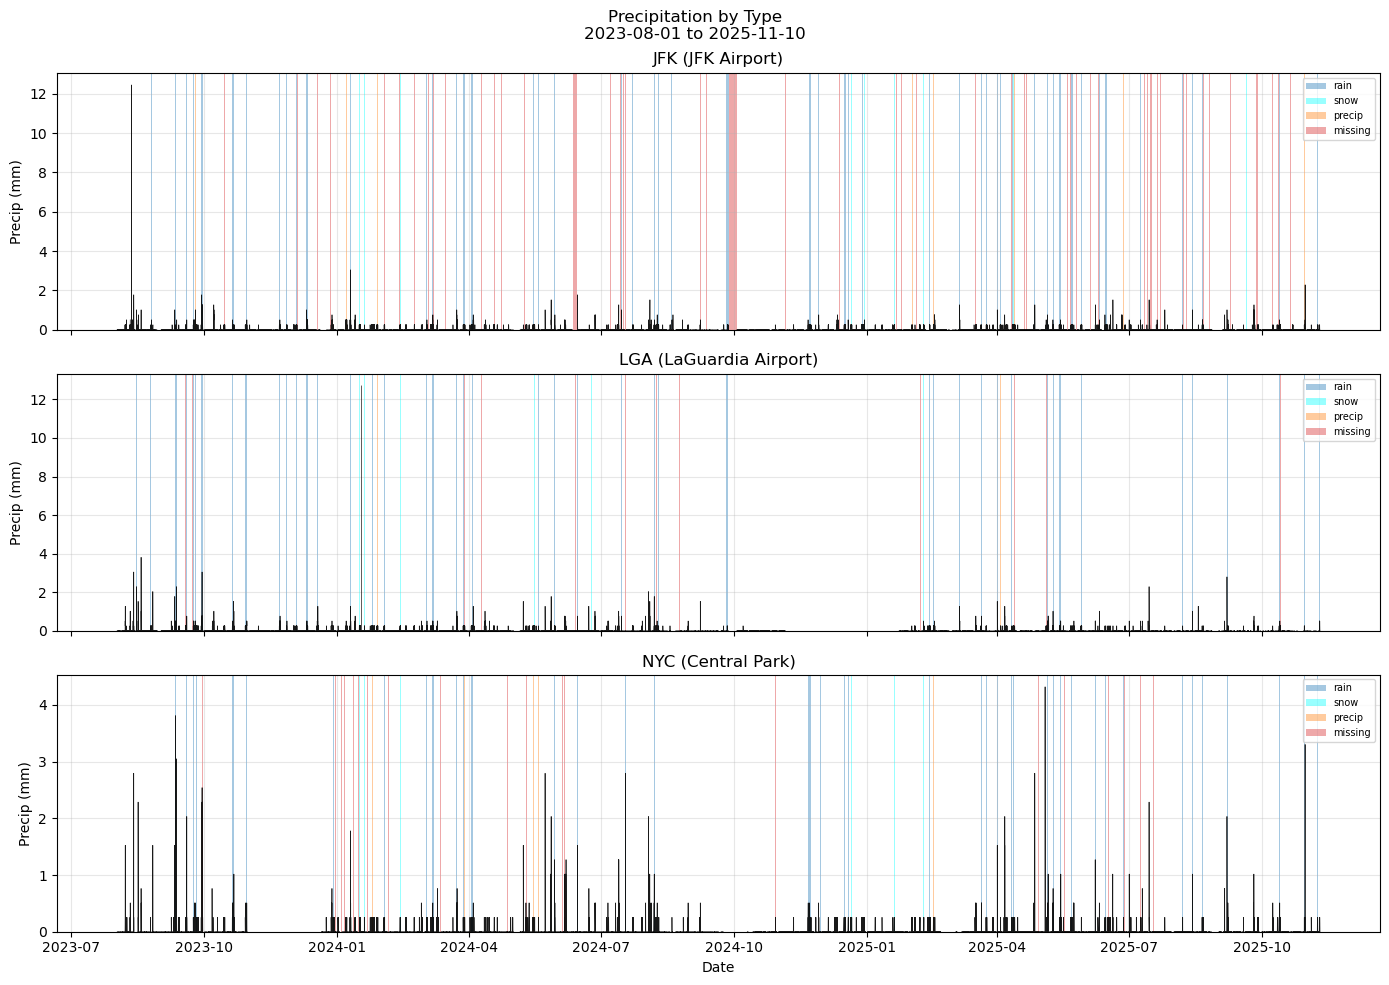

In [29]:

get_precip_type_summary(processed_data)
plot_precip_by_type(processed_data, start_date=START_DATE, end_date=END_DATE)

(<Figure size 1400x1000 with 3 Axes>,
 array([<Axes: title={'center': 'JFK (JFK Airport)'}, ylabel='Precip (mm)'>,
        <Axes: title={'center': 'LGA (LaGuardia Airport)'}, ylabel='Precip (mm)'>,
        <Axes: title={'center': 'NYC (Central Park)'}, xlabel='Date', ylabel='Precip (mm)'>],
       dtype=object))

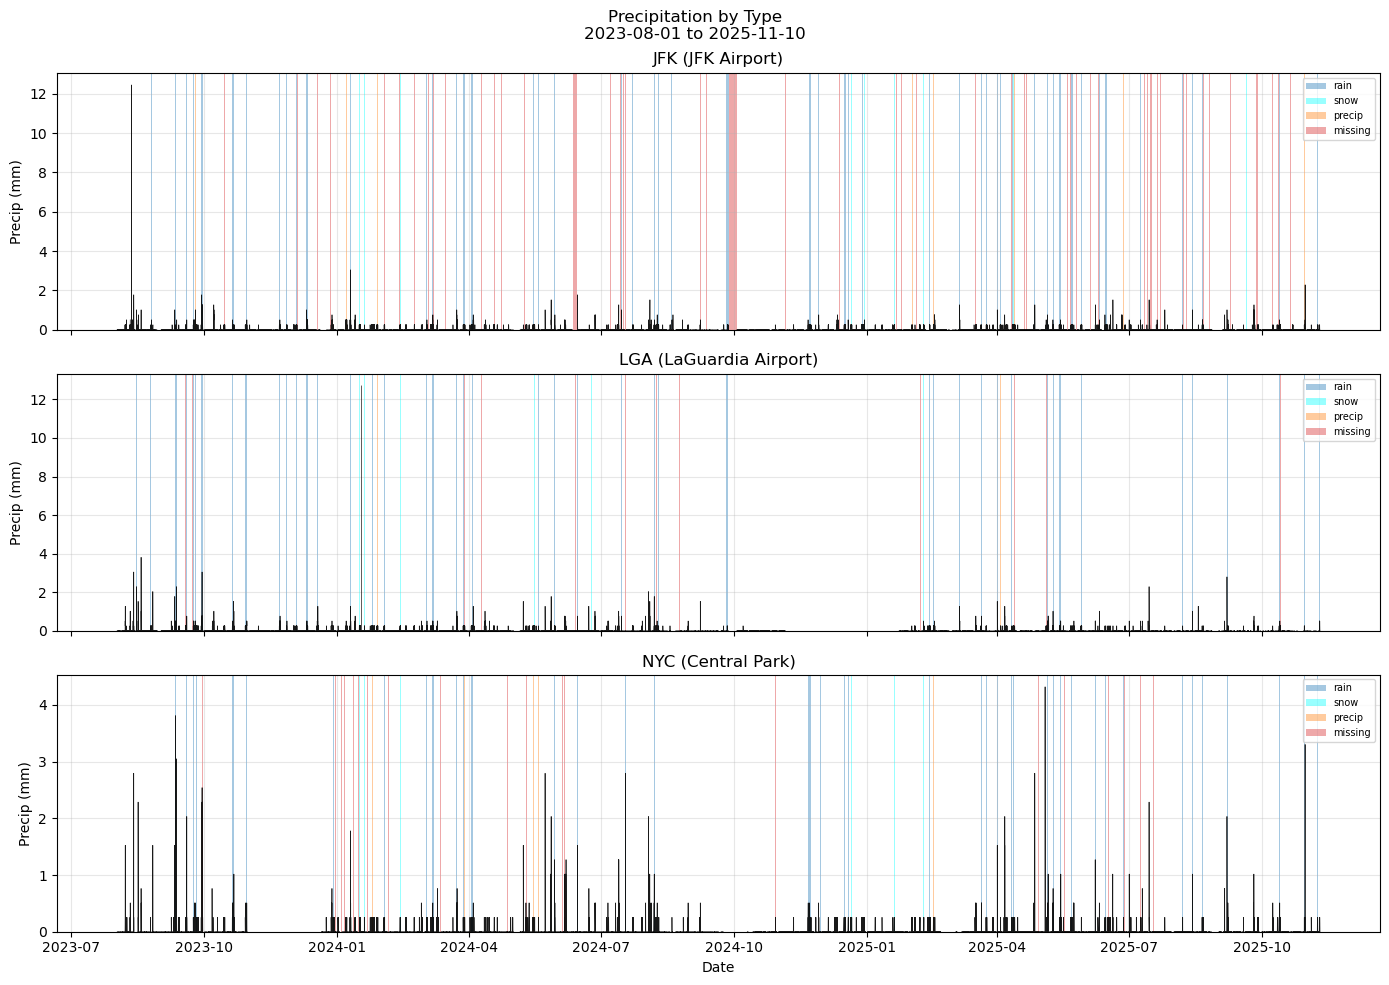

In [30]:
plot_precip_by_type(processed_data, start_date=START_DATE, end_date=END_DATE)

In [31]:
processed_data

{'JFK':                    datetime station_id     temp  dewpoint  avg_wind_speed  \
 0       2023-08-01 21:21:00        JFK        NaN         NaN        3.60108   
 1       2023-08-01 21:22:00        JFK  23.888889   13.333333        4.11552   
 2       2023-08-01 21:23:00        JFK  23.333333   13.333333        3.60108   
 3       2023-08-01 21:24:00        JFK  23.333333   13.333333        3.08664   
 4       2023-08-01 21:25:00        JFK  23.888889   13.888889        3.60108   
 ...                     ...        ...        ...         ...            ...   
 1069609 2025-11-09 23:55:00        JFK  15.000000   14.444444        1.02888   
 1069610 2025-11-09 23:56:00        JFK  15.000000   14.444444        1.02888   
 1069611 2025-11-09 23:57:00        JFK  15.000000   13.888889        1.54332   
 1069612 2025-11-09 23:58:00        JFK  15.000000   14.444444        1.54332   
 1069613 2025-11-09 23:59:00        JFK  15.000000   14.444444        2.05776   
 
          wind_dir_deg

In [32]:
# Cell 7: Resample to custom interval
# Options: '5min', '10min', '15min', '30min', '1H'

RESAMPLE_INTERVAL = '5min'

resampled_data = resample_all_stations(processed_data, interval=RESAMPLE_INTERVAL)

# Check totals still match
print(f"\n{RESAMPLE_INTERVAL} totals (should match 1-min):")
for station_id, df in resampled_data.items():
    total = df['precip_incremental'].sum()
    print(f"  {station_id}: {total:.1f} mm")

Resampling to 5min intervals...
  JFK: 239,360 rows
  LGA: 239,373 rows
  NYC: 239,355 rows
✓ Resampling to 5min complete


5min totals (should match 1-min):
  JFK: 2359.2 mm
  LGA: 2210.1 mm
  NYC: 2302.3 mm


In [33]:
# Cell 8: Compute accumulated precipitation
accumulated = compute_accumulated_all(processed_data, START_DATE, END_DATE)

print("Accumulated totals:")
for station_id, df in accumulated.items():
    final = df['accumulated_mm'].iloc[-1]
    print(f"  {station_id}: {final:.1f} mm")

Accumulated totals:
  JFK: 2359.2 mm
  LGA: 2210.1 mm
  NYC: 2302.3 mm


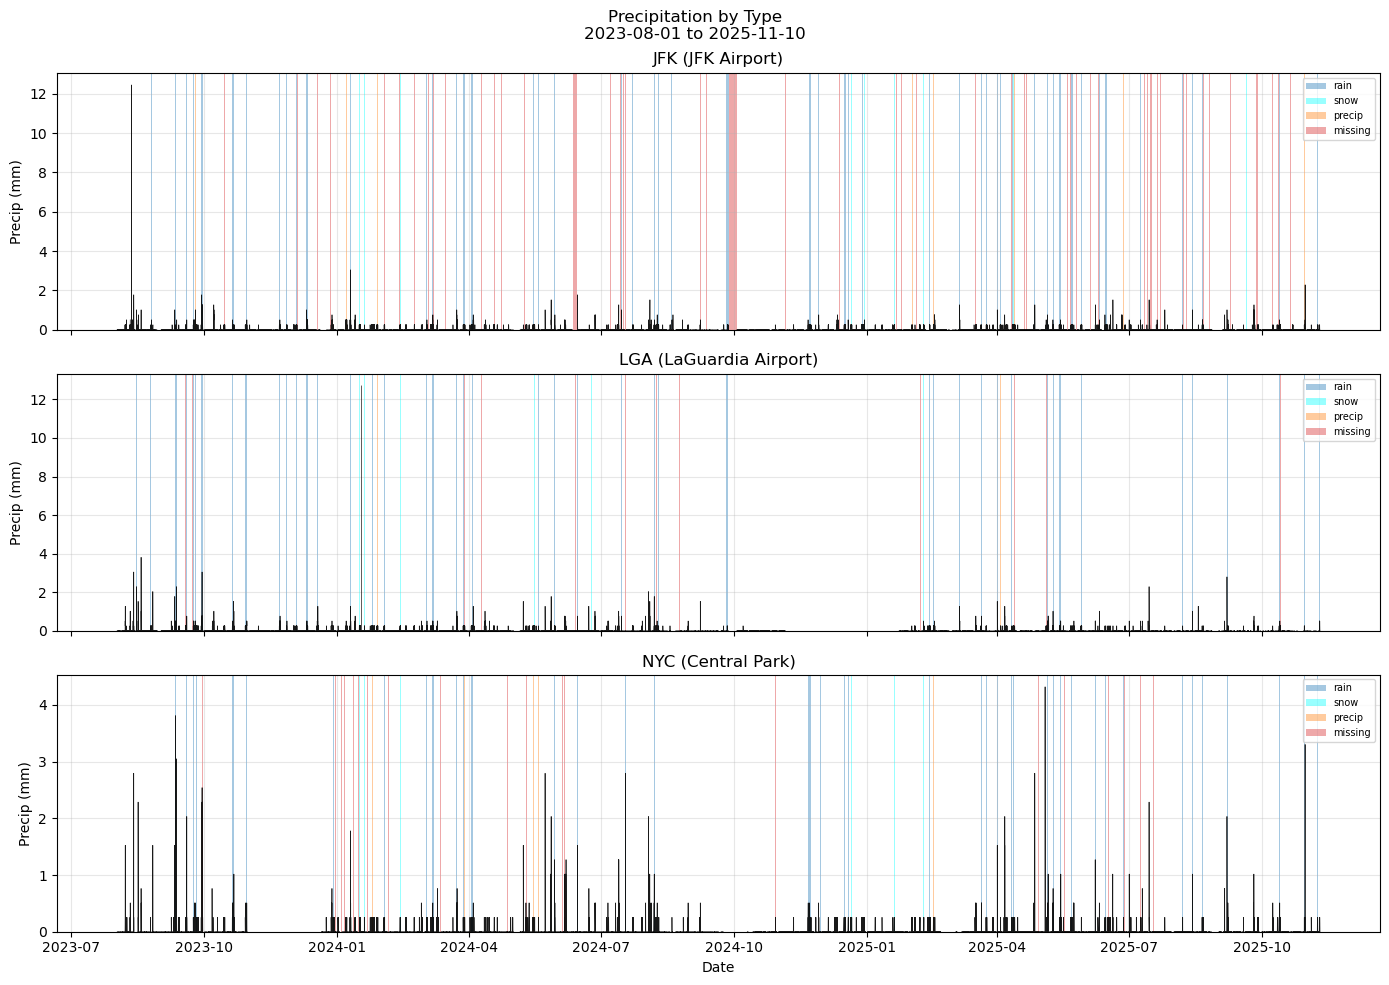

In [34]:
# Cell 10: Plot precipitation by type
fig, axes = plot_precip_by_type(
    processed_data,
    start_date=START_DATE,
    end_date=END_DATE
)
plt.show()

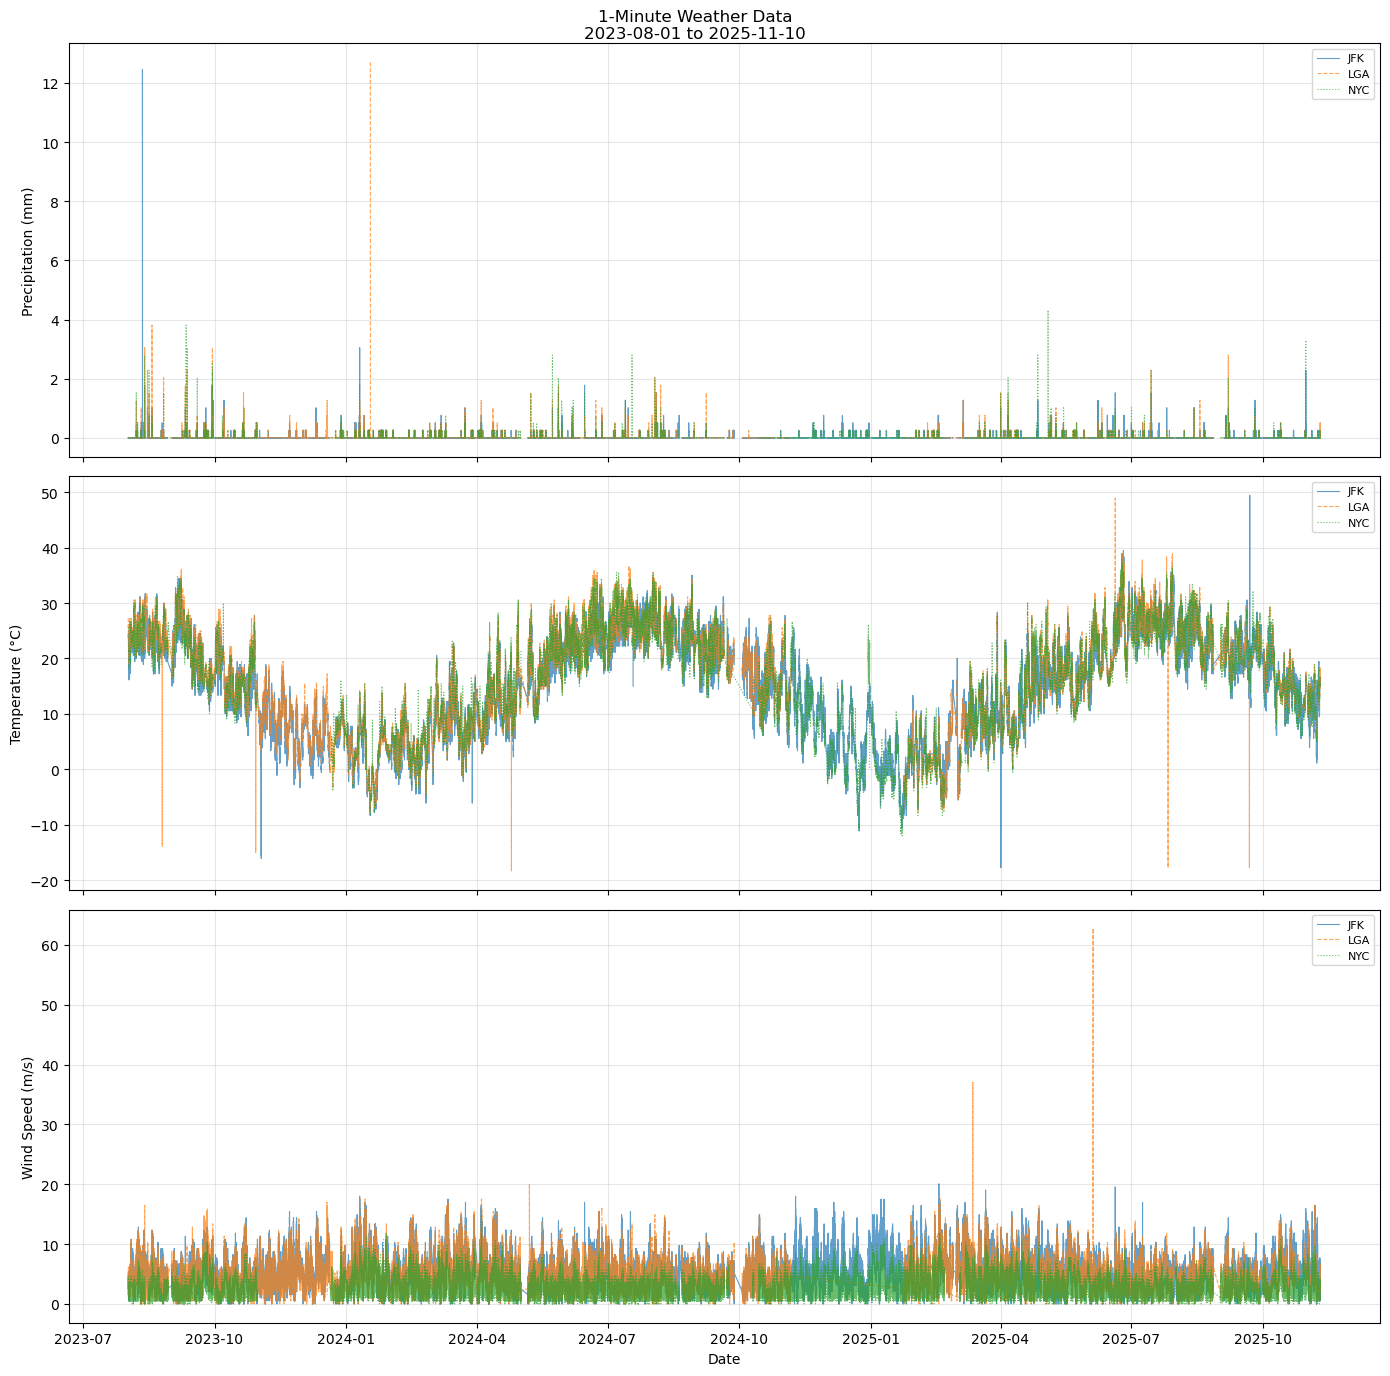

In [35]:
# Cell 11: Plot all weather parameters
fig, axes = plot_weather_subplots(
    processed_data,
    params=['precip_incremental', 'temp', 'avg_wind_speed'],
    start_date=START_DATE,
    end_date=END_DATE,
    figsize=(14, 14), ylims= [0,5],
    title_prefix='1-Minute' 
)
plt.show()

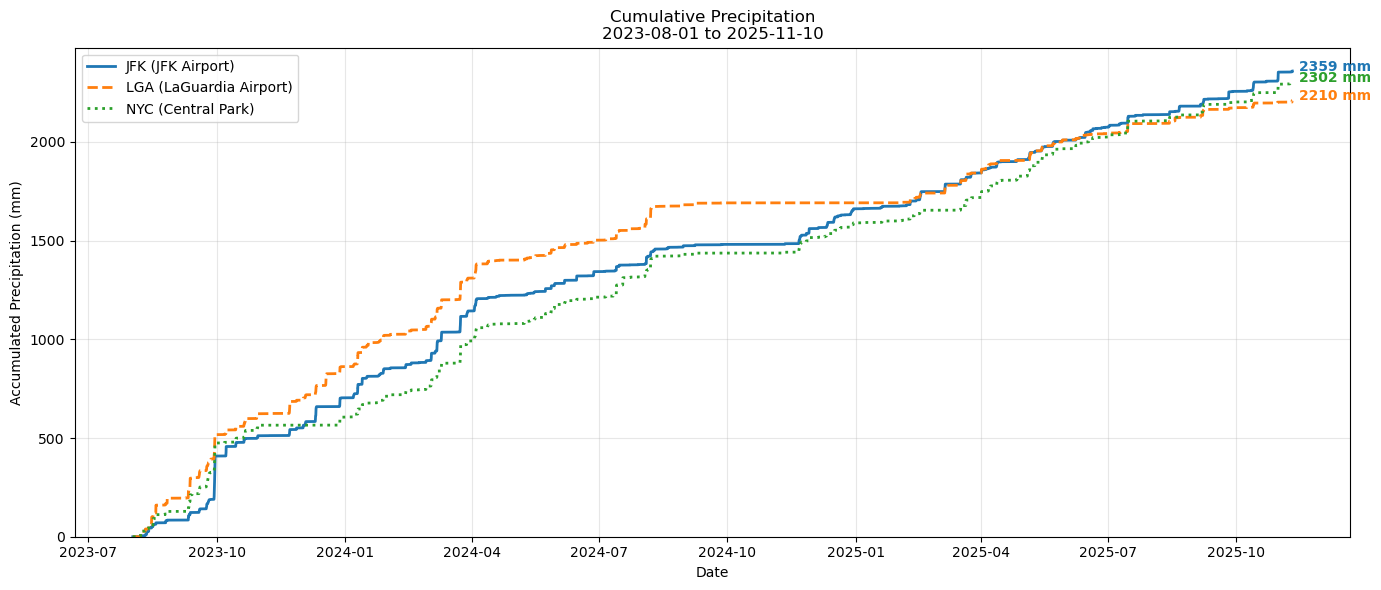

In [36]:
# Cell 12: Plot accumulated precipitation
fig, ax = plot_accumulated(
    accumulated,
    start_date=START_DATE,
    end_date=END_DATE
)
plt.show()

In [39]:
# Cell 13: Save data
# Flags to control what to save
SAVE_1MIN = True
SAVE_RESAMPLED = False
SAVE_INDIVIDUAL = True
SAVE_COMBINED = False

# Check format before saving
print('Checking format before save...')
format_results = check_format(processed_data)

# Check if all valid
all_valid = all(r['valid'] for r in format_results.values())

if not all_valid:
    response = input('Format issues found. Save anyway? (y/n): ').strip().lower()
    if response != 'y':
        print('Save aborted.')
        SAVE_1MIN = False
        SAVE_RESAMPLED = False

if SAVE_1MIN:
    save_data(
        processed_data, 
        DATA_DIR, 
        prefix='1min',
        save_individual=SAVE_INDIVIDUAL,
        save_combined=SAVE_COMBINED
    )

if SAVE_RESAMPLED:
    save_data(
        resampled_data, 
        DATA_DIR, 
        prefix=RESAMPLE_INTERVAL,
        save_individual=SAVE_INDIVIDUAL,
        save_combined=SAVE_COMBINED
    )


Saving to: /Users/drorjac/OpenMesh_pynncml/src/data/noaa_asos
----------------------------------------
  ✓ JFK_1min.csv (1,069,614 rows)
  ✓ LGA_1min.csv (861,988 rows)
  ✓ NYC_1min.csv (888,254 rows)
----------------------------------------
✓ Save complete: /Users/drorjac/OpenMesh_pynncml/src/data/noaa_asos



In [38]:
# Cell 14: Summary
print("=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"\nPeriod: {START_DATE.date()} to {END_DATE.date()}")
print(f"Stations: {len(processed_data)}")
print(f"Resample interval: {RESAMPLE_INTERVAL}")
print(f"\nVariables: temp, dewpoint, avg_wind_speed, max_wind_speed,")
print(f"           wind_dir_deg, visibility_km, precip_type, precip_incremental")
print(f"\nPrecipitation totals:")
for station_id, df in processed_data.items():
    total = df['precip_incremental'].sum()
    print(f"  {station_id}: {total:.1f} mm")
print(f"\nOutput directory: {DATA_DIR.resolve()}")
print("\n" + "=" * 60)
print("✓ COMPLETE")

SUMMARY

Period: 2023-08-01 to 2025-11-10
Stations: 3
Resample interval: 5min

Variables: temp, dewpoint, avg_wind_speed, max_wind_speed,
           wind_dir_deg, visibility_km, precip_type, precip_incremental

Precipitation totals:
  JFK: 2359.2 mm
  LGA: 2210.1 mm
  NYC: 2302.3 mm

Output directory: /Users/drorjac/OpenMesh_pynncml/src/data/noaa_asos

✓ COMPLETE
